# Statistical assessment of cost vectors

**Humanoid | 20 arms | simulated rewards only**

Panel (a) retains the Ljung-Box diagnostic at **1% significance**, now with an **80% binomial null reference band**. Panel (b) tests whether each arm's probability of falling inside a pooled quantile rectangle is **at least 80%**, also at **1% significance**, for three rectangle widths.

This notebook reads the completed result; it does not simulate trajectories. The second question is cost-range coverage, not equality of means or distributions. Non-rejection is not proof that coverage is at least 80%.

In [1]:
from pathlib import Path
import pickle
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import Markdown, display

root = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "Statistical tests" / "setup.json").is_file()), None)
if root is None:
    raise FileNotFoundError("Run Statistical tests/script.py before opening the results.")
folder = root / "Statistical tests"
setup = json.loads((folder / "setup.json").read_text(encoding="utf-8"))
result_path = folder / setup["output_file"]
with result_path.open("rb") as stream:
    result = pickle.load(stream)
analysis = result["analysis"]
if not result["completed_runs"].all() or analysis is None or not analysis["complete"]:
    raise ValueError("The simulation and statistical analysis must both be complete.")
config = analysis["configuration"]
if config != setup["statistics"]:
    raise ValueError("Saved test settings differ from setup.json; finish the configured analysis first.")
horizons = analysis["horizons"]
lb_summaries = analysis["lb_by_significance_level"]
coverage_result = analysis["quantile_coverage"]
coverage_config = config["quantile_coverage"]
rejection_rate_cutoff = 0.20
colors = ["#215b9c", "#d17a16", "#a13d62"]
markers = ["o", "s", "^"]
linestyles = ["-", "--", ":"]
n_runs = result["setup"]["n_independent_runs"]
counts = analysis["arm_counts_by_iteration"]
plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "stix",
                     "font.size": 12, "axes.labelsize": 13,
                     "axes.titlesize": 14, "figure.dpi": 140,
                     "svg.fonttype": "none"})
display(Markdown(
    f"**Ljung-Box trajectories:** {n_runs}; **maximum lag:** {config['ljung_box']['max_lag']}. "
    f"**Calibration trajectories:** {len(coverage_result['calibration_run_indices'])}; "
    f"**evaluation trajectories:** {len(coverage_result['evaluation_run_indices'])}. "
    f"**Evaluated vectors per arm/horizon:** {coverage_result['counts'].min()}-{coverage_result['counts'].max()}. "
    f"**Minimum required coverage:** {coverage_config['minimum_coverage']:.0%}; "
    f"**significance:** {coverage_config['alpha']:.0%}; "
    f"**descriptive interval confidence:** {config['confidence_level']:.0%}."
))

def format_axis(ax):
    ax.set_xlabel(r"Horizon $p$")
    ax.set_xlim(horizons.min()-2, horizons.max()+2)
    ax.set_xticks([p for p in horizons if p % 20 == 0 or p == horizons[-1]])
    ax.set_ylim(-0.025, 1.055)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(False)


**Ljung-Box trajectories:** 600; **maximum lag:** 5. **Calibration trajectories:** 300; **evaluation trajectories:** 300. **Evaluated vectors per arm/horizon:** 6-29. **Minimum required coverage:** 80%; **significance:** 1%; **descriptive interval confidence:** 80%.

## (a) Independence diagnostic

The multivariate Ljung-Box diagnostic uses lag 5 and 4,999 joint-row permutations per trajectory prefix. Only the 1% significance level is displayed. The shading is the **pointwise 80% binomial null reference band**, not an interval for the observed rejection rate. Changing its confidence level does not change test decisions. The 20% horizontal cutoff is descriptive. Non-rejection does not establish independence.

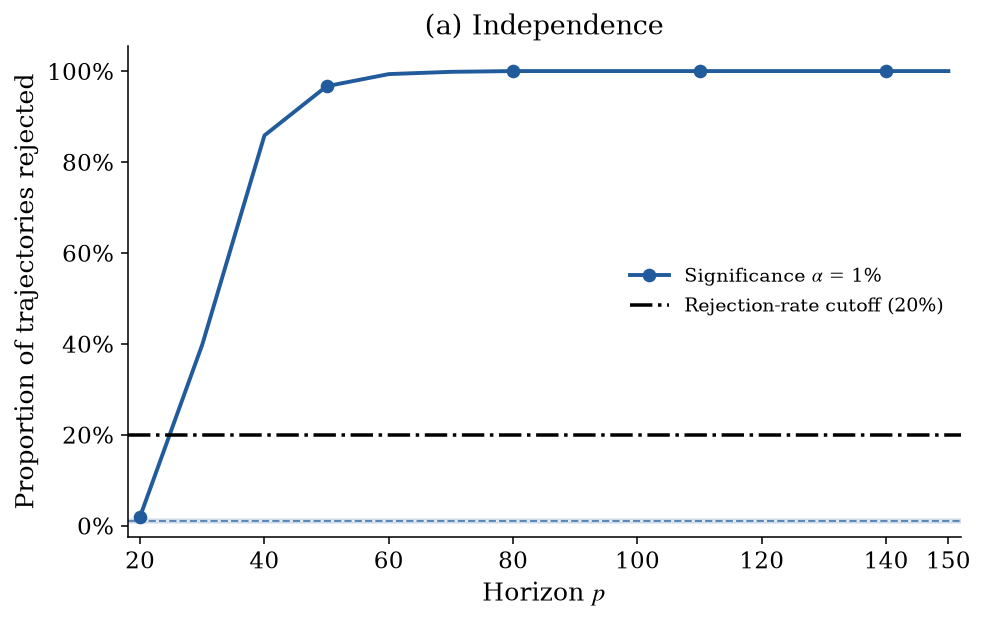

In [2]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for i, summary in enumerate(lb_summaries):
    alpha = summary["alpha"]
    low, high = summary["lb_null_reference_band"]
    ax.axhspan(low, high, color=colors[i], alpha=0.12)
    ax.axhline(alpha, color=colors[i], linestyle="--", linewidth=1.0, alpha=0.7)
    ax.plot(horizons, summary["lb_rejection_rate"], color=colors[i],
            marker=markers[i], markevery=(i, 3), markersize=6,
            linestyle=linestyles[i], linewidth=2.0,
            label=rf"Significance $\alpha$ = {100*alpha:g}%")
ax.axhline(rejection_rate_cutoff, color="black", linestyle="-.", linewidth=1.8,
           label=f"Rejection-rate cutoff ({rejection_rate_cutoff:.0%})")
format_axis(ax)
ax.set_ylabel("Proportion of trajectories rejected")
ax.set_title("(a) Independence")
ax.legend(frameon=False, fontsize=10, loc="center right")
fig.tight_layout()
fig.savefig(folder / "Independence.png", dpi=300, bbox_inches="tight")
fig.savefig(folder / "Independence.svg", bbox_inches="tight")
plt.show()


## (b) Coverage of pooled quantile rectangles

A fixed, reproducible split reserves 300 complete trajectories for calibration and 300 for evaluation. Calibration pools both cost coordinates across **all arms and all 150 iterations**. Separate coordinate-wise quantiles define three rectangles:

- q = 5%: 5th to 95th percentiles.
- q = 10%: 10th to 90th percentiles.
- q = 20%: 20th to 80th percentiles.

For each horizon, **one uniform random iteration per evaluation trajectory** supplies a bivariate observation. Selection is independent of costs and arms and is shared across the three rectangles. This gives independent Bernoulli membership observations across trajectories without assuming independence within a trajectory. It uses fewer observations than pooling every iteration; the sample sizes are displayed above. The same uniform draw is reused to couple horizons, so horizons are not independent.

For each arm, an exact one-sided binomial test assesses

$$H_0:\ \Pr(\mathbf C_T\in R\mid\ell)\geq0.80
\quad\text{against}\quad
H_1:\ \Pr(\mathbf C_T\in R\mid\ell)<0.80,$$

where $T$ is uniformly distributed over the current prefix and $R$ is the calibrated rectangle. Holm correction covers 20 arms separately within each rectangle/horizon, at **1% significance**. There is no correction across the three exploratory widths or horizons.

The target averages over iteration positions in a prefix; it does not require 80% coverage at every individual iteration. Coordinate quantiles do not imply the same joint coverage. Boundaries are inclusive, including repeated values such as zero. All bounds are fixed from calibration data and never fitted to the held-out outcomes.

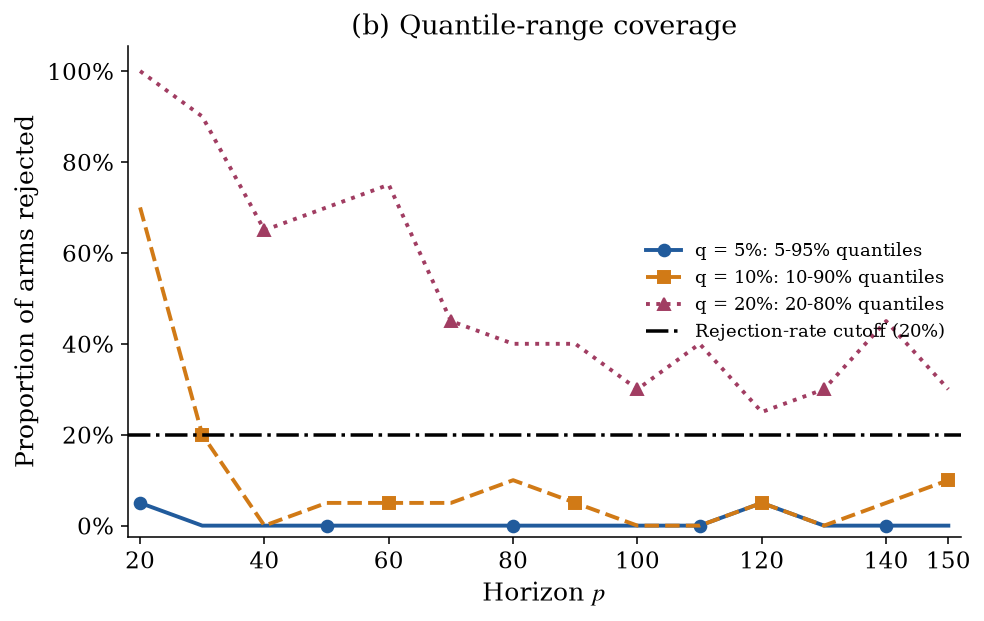

In [3]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
for i, band in enumerate(coverage_config["bands"]):
    ax.plot(horizons, coverage_result["rejection_rate"][i], color=colors[i],
            marker=markers[i], markevery=(i, 3), markersize=6,
            linestyle=linestyles[i], linewidth=2,
            label=f"{band['name']}: {100*band['lower']:g}-{100*band['upper']:g}% quantiles")
ax.axhline(rejection_rate_cutoff, color="black", linestyle="-.", linewidth=1.8,
           label=f"Rejection-rate cutoff ({rejection_rate_cutoff:.0%})")
format_axis(ax)
ax.set_yticks(np.linspace(0, 1, 6))
ax.set_ylabel("Proportion of arms rejected")
ax.set_title("(b) Quantile-range coverage")
ax.legend(frameon=False, fontsize=9, loc="center right")
fig.tight_layout()
fig.savefig(folder / "Quantile coverage.png", dpi=300, bbox_inches="tight")
fig.savefig(folder / "Quantile coverage.svg", bbox_inches="tight")
plt.show()


## Observed coverage and interpretation

The following tables show observed membership proportions and per-arm **80% two-sided Clopper-Pearson intervals** at the final horizon. These are descriptive intervals; they are neither simultaneous nor the intervals used to make the **1% one-sided, Holm-adjusted** rejection decisions. The significance and confidence settings serve different purposes.

Non-rejection can reflect limited power and must not be called proof of sufficient coverage. The pooled quantile regions are a new criterion and do not validate the original iid assumption. Earlier MANOVA and energy-test results remain preserved.

Reference: [SciPy exact binomial test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.binomtest.html).

In [4]:
import pandas as pd
rows = []
for bi, band in enumerate(coverage_config["bands"]):
    for arm, margin in enumerate(result["arm_values"]):
        lo, hi = coverage_result["coverage_intervals"][bi, -1, arm]
        rows.append({"Rectangle": band["name"], "Arm": margin,
                     "n": coverage_result["counts"][-1, arm],
                     "Observed coverage": coverage_result["coverage"][bi, -1, arm],
                     "80% CI lower": lo, "80% CI upper": hi,
                     "Holm p-value": coverage_result["pvalue_holm"][bi, -1, arm],
                     "Rejected": coverage_result["rejected"][bi, -1, arm]})
display(pd.DataFrame(rows).round(4))
print("Rectangle bounds in original units: overhead KiB, instability dimensionless")
for band, bounds in zip(coverage_config["bands"], coverage_result["rectangles_original_units"]):
    print(band["name"], "lower:", bounds[0], "upper:", bounds[1])


,Rectangle,Arm,n,Observed coverage,80% CI lower,80% CI upper,Holm p-value,Rejected
0,q = 5%,-10.0000,14,0.6429,0.4369,0.8149,1.0000,False
1,q = 5%,-8.4211,12,0.6667,0.4410,0.8458,1.0000,False
2,q = 5%,-6.8421,17,0.6471,0.4626,0.8028,1.0000,False
3,q = 5%,-5.2632,16,0.8125,0.6288,0.9290,1.0000,False
4,q = 5%,-3.6842,23,0.9130,0.7848,0.9766,1.0000,False
5,q = 5%,-2.1053,15,0.8000,0.6072,0.9241,1.0000,False
6,q = 5%,-0.5263,14,0.5714,0.3691,0.7568,0.8771,False
7,q = 5%,1.0526,9,1.0000,0.7743,1.0000,1.0000,False
8,q = 5%,2.6316,9,1.0000,0.7743,1.0000,1.0000,False
9,q = 5%,4.2105,15,0.9333,0.7644,0.9930,1.0000,False


Rectangle bounds in original units: overhead KiB, instability dimensionless
q = 5% lower: [0.         0.45030952] upper: [3.36726914e+04 8.95619226e-01]
q = 10% lower: [0.         0.50889649] upper: [3.1178418e+04 8.7980486e-01]
q = 20% lower: [0.         0.61405387] upper: [2.74370078e+04 8.56794148e-01]
